## Assignment Linguistic Forensic Audit: NER & POS Drift Group 7

### Set up environment


In [1]:
import sys
from pathlib import Path
import pandas as pd

ROOT = Path("..").resolve()
sys.path.append(str(ROOT))

RAW_DIR = ROOT / "data" / "raw" / "paraphrased_datasets"
OUT_DIR = ROOT / "experiments" / "stylometry_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Task 1 Data Processing & Version Alignment

In [2]:
files = sorted(RAW_DIR.glob("*_paraphrased.csv"))
[p.name for p in files]

['cmv_paraphrased.csv',
 'eli5_paraphrased.csv',
 'sci_gen_paraphrased.csv',
 'tldr_paraphrased.csv',
 'wp_paraphrased.csv',
 'xsum_paraphrased.csv',
 'yelp_paraphrased.csv']

In [3]:
dfs = []
for f in files:
    df = pd.read_csv(f)
    df["dataset"] = f.name.replace("_paraphrased.csv", "")
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.shape

(420012, 5)

In [4]:
df_all.columns = [c.strip().lower() for c in df_all.columns]

if "version" not in df_all.columns and "version_name" in df_all.columns:
    df_all = df_all.rename(columns={"version_name": "version"})

required_cols = ["dataset", "key", "source", "text", "version"]
missing = [c for c in required_cols if c not in df_all.columns]
print("missing:", missing)

df_all[required_cols].head()

missing: []


,dataset,key,source,text,version
0,cmv,cmv-258,Tsinghua,"Before I begin, I would like to point somethin...",original
1,cmv,cmv-258,Eleuther-AI,"Before I begin, I would like to point somethin...",original
2,cmv,cmv-258,LLAMA,"Before I begin, I would like to point somethin...",original
3,cmv,cmv-258,OpenAI,"Before I begin, I would like to point somethin...",original
4,cmv,cmv-258,BigScience,"Before I begin, I would like to point somethin...",original


In [5]:
unique_versions = sorted(df_all["version"].dropna().astype(str).str.strip().unique().tolist())
print("num unique versions:", len(unique_versions))
unique_versions

num unique versions: 22


['chatgpt',
 'chatgpt_chatgpt',
 'chatgpt_chatgpt_chatgpt',
 'dipper',
 'dipper(high)',
 'dipper(high)_dipper(high)',
 'dipper(high)_dipper(high)_dipper(high)',
 'dipper(low)',
 'dipper(low)_dipper(low)',
 'dipper(low)_dipper(low)_dipper(low)',
 'dipper_dipper',
 'dipper_dipper_dipper',
 'original',
 'palm',
 'palm_palm',
 'palm_palm_palm',
 'pegasus(full)',
 'pegasus(full)_pegasus(full)',
 'pegasus(full)_pegasus(full)_pegasus(full)',
 'pegasus(slight)',
 'pegasus(slight)_pegasus(slight)',
 'pegasus(slight)_pegasus(slight)_pegasus(slight)']

In [6]:
task1 = df_all.copy()
task1["version"] = task1["version"].astype(str).str.strip()

target_versions = {
    "original",
    "orignal",
    "chatgpt",
    "dipper(high)",
    "dipper(low)",
    "pegasus(slight)"
}

task1 = task1[task1["version"].isin(target_versions)].copy()
task1.shape

(96554, 5)

In [7]:
task1["version_norm"] = task1["version"].replace({
    "original": "text_T0",
    "orignal": "text_T0",
    "chatgpt": "text_chatgpt",
    "dipper(high)": "text_dipper_high",
    "dipper(low)": "text_dipper_low",
    "pegasus(slight)": "text_pegasus_slight"
})

task1[["version", "version_norm"]].drop_duplicates().sort_values("version")

,version,version_norm
1626,chatgpt,text_chatgpt
30527,dipper(high),text_dipper_high
25649,dipper(low),text_dipper_low
0,original,text_T0
8105,pegasus(slight),text_pegasus_slight


In [8]:
paired = (
    task1.pivot_table(
        index=["dataset", "key", "source"],
        columns="version_norm",
        values="text",
        aggfunc="first"
    )
    .reset_index()
)

paired.shape
paired.head()

version_norm,dataset,key,source,text_T0,text_chatgpt,text_dipper_high,text_dipper_low,text_pegasus_slight
0,cmv,cmv-1079,BigScience,Please note before reading: Please do not down...,Please be aware that I kindly request not to d...,A style of camouflaging the impossible became...,Please note before reading: Do not downvote m...,Please note before reading: Please do not down...
1,cmv,cmv-1079,Eleuther-AI,Please note before reading: Please do not down...,I kindly request that you refrain from downvot...,"Remember once again I say, downvoting is not ...",Please note before reading: Please do not dow...,Please don't downvote my comments and replies ...
2,cmv,cmv-1079,Human,Please note before reading: Please do not down...,I kindly request that you refrain from downvot...,"But being presented with their little pearl, ...",I have been a part of several CMVs where I wa...,Please don't downvote my comments and replies ...
3,cmv,cmv-1079,LLAMA,Please note before reading: Please do not down...,Please take note before reading: Please refrai...,"i. , ,,,,, , , . So let ...",Please note before reading: Please do not dow...,Please note before reading: Please do not down...
4,cmv,cmv-1079,OpenAI,Please note before reading: Please do not down...,Kindly take note before reading: I kindly requ...,"There, the statesman opened the packet. A: Th...",Please note before reading: Please do not dow...,Please note before reading: Please do not down...


In [9]:
expected_cols = [
    "dataset",
    "key",
    "source",
    "text_T0",
    "text_chatgpt",
    "text_dipper_high",
    "text_dipper_low",
    "text_pegasus_slight"
]

for col in expected_cols:
    if col not in paired.columns:
        paired[col] = pd.NA

paired = paired[expected_cols]
paired.head()

version_norm,dataset,key,source,text_T0,text_chatgpt,text_dipper_high,text_dipper_low,text_pegasus_slight
0,cmv,cmv-1079,BigScience,Please note before reading: Please do not down...,Please be aware that I kindly request not to d...,A style of camouflaging the impossible became...,Please note before reading: Do not downvote m...,Please note before reading: Please do not down...
1,cmv,cmv-1079,Eleuther-AI,Please note before reading: Please do not down...,I kindly request that you refrain from downvot...,"Remember once again I say, downvoting is not ...",Please note before reading: Please do not dow...,Please don't downvote my comments and replies ...
2,cmv,cmv-1079,Human,Please note before reading: Please do not down...,I kindly request that you refrain from downvot...,"But being presented with their little pearl, ...",I have been a part of several CMVs where I wa...,Please don't downvote my comments and replies ...
3,cmv,cmv-1079,LLAMA,Please note before reading: Please do not down...,Please take note before reading: Please refrai...,"i. , ,,,,, , , . So let ...",Please note before reading: Please do not dow...,Please note before reading: Please do not down...
4,cmv,cmv-1079,OpenAI,Please note before reading: Please do not down...,Kindly take note before reading: I kindly requ...,"There, the statesman opened the packet. A: Th...",Please note before reading: Please do not dow...,Please note before reading: Please do not down...


In [10]:
paired = paired.dropna(
    subset=["text_T0", "text_chatgpt", "text_dipper_high", "text_pegasus_slight"]
)

print("paired.shape =", paired.shape)

paired.shape = (19182, 8)


In [11]:
preview = (
    paired.groupby("dataset", group_keys=False)
          .head(2)
          .reset_index(drop=True)
)

preview[[
    "dataset",
    "key",
    "source",
    "text_T0",
    "text_chatgpt",
    "text_dipper_high",
    "text_dipper_low",
    "text_pegasus_slight"
]]

version_norm,dataset,key,source,text_T0,text_chatgpt,text_dipper_high,text_dipper_low,text_pegasus_slight
0,cmv,cmv-1079,BigScience,Please note before reading: Please do not down...,Please be aware that I kindly request not to d...,A style of camouflaging the impossible became...,Please note before reading: Do not downvote m...,Please note before reading: Please do not down...
1,cmv,cmv-1079,Eleuther-AI,Please note before reading: Please do not down...,I kindly request that you refrain from downvot...,"Remember once again I say, downvoting is not ...",Please note before reading: Please do not dow...,Please don't downvote my comments and replies ...
2,eli5,eli5-16706,BigScience,It's your body that is preparing to fight for ...,"When faced with a threatening situation, your ...",They had gone to watch—a perilous walk—from L...,Because your brain perceives it as a threat. ...,It's your body that is preparing to fight for ...
3,eli5,eli5-16706,Eleuther-AI,It's your body that is preparing to fight for ...,When your brain perceives something threatenin...,You must have foreseen some dreadful monster ...,Because your brain takes it as a threat. It i...,It's your body that is preparing to fight for ...
4,sci_gen,sci_gen-1744,BigScience,"In this article, we investigate the transient ...",This article explores the behavior of packetsb...,These were three years of great difficulty. T...,"In this article, we investigate the transient...","In this article, we investigate the transient ..."
5,sci_gen,sci_gen-1744,Human,"In this article, we investigate whispered-to n...",This article examines a method for converting ...,Gulathy blew two pitcherfuls of tea for himse...,"In this article, we investigate a whisper-to-...","In this article, we investigate whispered-to n..."
6,tldr,tldr-2826,BigScience,Tensorflow Privacy implements Tensorflow optim...,Tensorflow Privacy is a library that enables t...,The next morning we went down to the little t...,Contribution to the research field: TensorFlo...,Machine learning models with differential priv...
7,tldr,tldr-2826,Eleuther-AI,Tensorflow Privacy implements Tensorflow optim...,Tensorflow Privacy provides Tensorflow optimiz...,There was a chance of seeing Amsden's line in...,TensorFlow privacy is an implementation of Te...,Machine learning models with differential priv...
8,wp,wp-1198,BigScience,"""and those are the terms. I'm sorry."" The Athe...","""Those are the terms, and I apologize,"" said t...",Atheism pressed her with even greater persuas...,"The atheist, a young female hipster in thick-...","""and those are the terms. I'm sorry. The Athei..."
9,wp,wp-1198,Eleuther-AI,"""and those are the terms. I'm sorry."" The Athe...","""Those are the conditions, and I apologize."" T...","Ah, that’s really too bad!” “Well, that’s abo...","The Atheist, a young female hipster in thick-...","""and those are the terms. I'm sorry. The Athei..."


In [12]:
print("dataset column present:", "dataset" in paired.columns)
print("key column present:", "key" in paired.columns)
print("source column present:", "source" in paired.columns)

dataset column present: True
key column present: True
source column present: True


# Task 2  POS Tagging: Stylistic Drift 

## POS Extraction

In [13]:
!pip install spacy


In [14]:
# from sympy import python
# run this in terminal to download the spacy model
# python -m spacy download en_core_web_sm

In [15]:
paired = pd.read_pickle(OUT_DIR / "paired_all.pkl")
paired.shape

(19182, 7)

In [16]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

In [17]:
from collections import Counter

ALL_UPOS = [
    "ADJ","ADP","ADV","AUX","CCONJ","DET","INTJ","NOUN",
    "NUM","PART","PRON","PROPN","PUNCT","SCONJ","SYM","VERB","X"
]

def get_pos_distribution(text):
    doc = nlp(text)
    
    counts = {pos: 0 for pos in ALL_UPOS}
    total = 0
    
    for token in doc:
        if not token.is_space:
            counts[token.pos_] += 1
            total += 1
    
    if total == 0:
        return {pos:0.0 for pos in ALL_UPOS}
    
    return {pos: counts[pos] / total for pos in ALL_UPOS}

In [18]:
pos_T0 = []
pos_dipper = []
pos_chatgpt = []
for i, row in paired.iterrows():
    pos_T0.append(get_pos_distribution(row["text_T0"]))
    pos_dipper.append(get_pos_distribution(row["text_dipper_high"]))
    pos_chatgpt.append(get_pos_distribution(row["text_chatgpt"]))
    if i % 2000 == 0:
        print("processed:", i)

processed: 0
processed: 2000
processed: 4000
processed: 6000
processed: 8000
processed: 10000
processed: 12000
processed: 14000
processed: 16000
processed: 18000


In [19]:
paired["pos_T0"] = pos_T0
paired["pos_dipper_high"] = pos_dipper
paired["pos_chatgpt"] = pos_chatgpt
paired.to_pickle(OUT_DIR / "pos_features.pkl")

## Task2b Cosine Similarity

In [20]:
import numpy as np

In [21]:
ALL_POS = [
    "ADJ", "ADP", "ADV", "AUX", "CCONJ", "DET", "INTJ", "NOUN",
    "NUM", "PART", "PRON", "PROPN", "PUNCT", "SCONJ", "SYM", "VERB", "X"
]
def dict_to_vector(d, pos_list):
    return np.array([d.get(p, 0) for p in pos_list])

def cosine_similarity(a, b):
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return np.nan
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [22]:
cos_sims = []

for _, row in paired.iterrows():
    v1 = dict_to_vector(row["pos_T0"], ALL_POS)
    v2 = dict_to_vector(row["pos_dipper_high"], ALL_POS)
    
    cos_sims.append(cosine_similarity(v1, v2))

paired["cos_sim_dipper"] = cos_sims

In [23]:
cos_sims_chatgpt = []

for _, row in paired.iterrows():
    v1 = dict_to_vector(row["pos_T0"], ALL_POS)
    v2 = dict_to_vector(row["pos_chatgpt"], ALL_POS)
    cos_sims_chatgpt.append(cosine_similarity(v1, v2))

paired["cos_sim_chatgpt"] = cos_sims_chatgpt

In [34]:
dataset_stats = (
    paired.groupby("dataset")[["cos_sim_dipper", "cos_sim_chatgpt"]]
          .agg(["mean", "std"])
)

# 展示表格
dataset_stats

version_norm cos_sim_dipper           cos_sim_chatgpt          
                       mean       std            mean       std
dataset                                                        
cmv                0.913364  0.062945        0.971421  0.026798
eli5               0.884545  0.091260        0.959563  0.042787
sci_gen            0.853451  0.093728        0.976796  0.048689
tldr               0.854831  0.094720        0.974069  0.025686
wp                 0.929992  0.065582        0.964483  0.052165
xsum               0.860164  0.097962        0.971637  0.035219
yelp               0.879276  0.090203        0.960819  0.052792

In [35]:
for ds, row in dataset_stats.iterrows():
    d_mean = row[("cos_sim_dipper", "mean")]
    d_std  = row[("cos_sim_dipper", "std")]
    c_mean = row[("cos_sim_chatgpt", "mean")]
    c_std  = row[("cos_sim_chatgpt", "std")]

    print(f"{ds}:")
    print(f"  Dipper(high): {d_mean:.4f} ± {d_std:.4f}")
    print(f"  ChatGPT:      {c_mean:.4f} ± {c_std:.4f}\n")

cmv:
  Dipper(high): 0.9134 ± 0.0629
  ChatGPT:      0.9714 ± 0.0268

eli5:
  Dipper(high): 0.8845 ± 0.0913
  ChatGPT:      0.9596 ± 0.0428

sci_gen:
  Dipper(high): 0.8535 ± 0.0937
  ChatGPT:      0.9768 ± 0.0487

tldr:
  Dipper(high): 0.8548 ± 0.0947
  ChatGPT:      0.9741 ± 0.0257

wp:
  Dipper(high): 0.9300 ± 0.0656
  ChatGPT:      0.9645 ± 0.0522

xsum:
  Dipper(high): 0.8602 ± 0.0980
  ChatGPT:      0.9716 ± 0.0352

yelp:
  Dipper(high): 0.8793 ± 0.0902
  ChatGPT:      0.9608 ± 0.0528



In [36]:
mean_d = np.nanmean(paired["cos_sim_dipper"])
std_d  = np.nanstd(paired["cos_sim_dipper"])

mean_c = np.nanmean(paired["cos_sim_chatgpt"])
std_c  = np.nanstd(paired["cos_sim_chatgpt"])

print(f"Overall Dipper(high): {mean_d:.4f} ± {std_d:.4f}")
print(f"Overall ChatGPT:      {mean_c:.4f} ± {std_c:.4f}")

Overall Dipper(high): 0.8802 ± 0.0917
Overall ChatGPT:      0.9678 ± 0.0436


## Task 2c Human vs LLM


In [37]:
paired["group"] = paired["source"].apply(
    lambda x: "Human" if x == "Human" else "LLM"
)

paired[["dataset", "source", "group"]].head()

version_norm,dataset,source,group
0,cmv,BigScience,LLM
1,cmv,Eleuther-AI,LLM
2,cmv,Human,Human
3,cmv,LLAMA,LLM
4,cmv,OpenAI,LLM


In [38]:
dataset_group = (
    paired.groupby(["dataset", "group"])[["cos_sim_dipper", "cos_sim_chatgpt"]]
          .mean()
          .reset_index()
)

dataset_group

version_norm,dataset,group,cos_sim_dipper,cos_sim_chatgpt
0,cmv,Human,0.947482,0.978206
1,cmv,LLM,0.907025,0.970161
2,eli5,Human,0.901111,0.962706
3,eli5,LLM,0.881649,0.959013
4,sci_gen,Human,0.846501,0.988810
5,sci_gen,LLM,0.854854,0.974371
6,tldr,Human,0.836710,0.974456
7,tldr,LLM,0.858196,0.973997
8,wp,Human,0.959100,0.982008
9,wp,LLM,0.924034,0.960895


In [39]:
results = (
    dataset_group.groupby("group")[["cos_sim_dipper", "cos_sim_chatgpt"]]
                 .mean()
)

results

version_norm,cos_sim_dipper,cos_sim_chatgpt
group,,
Human,0.892367,0.973758
LLM,0.880340,0.967329


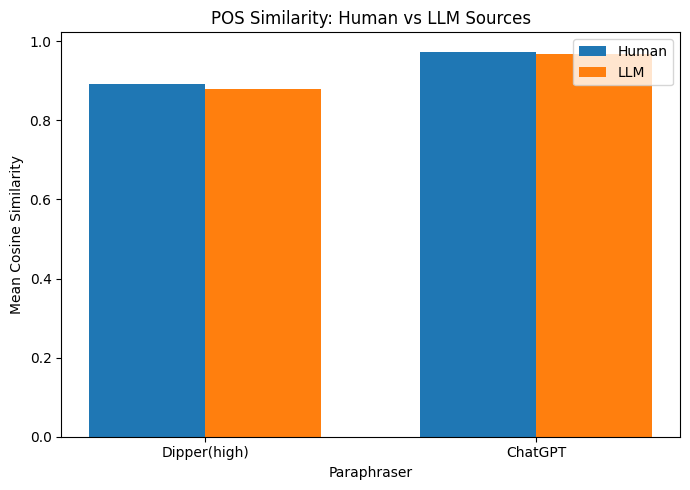

In [40]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Dipper(high)", "ChatGPT"]

human_vals = [
    results.loc["Human", "cos_sim_dipper"],
    results.loc["Human", "cos_sim_chatgpt"]
]

llm_vals = [
    results.loc["LLM", "cos_sim_dipper"],
    results.loc["LLM", "cos_sim_chatgpt"]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, human_vals, width, label="Human")
plt.bar(x + width/2, llm_vals, width, label="LLM")

plt.xticks(x, labels)
plt.xlabel("Paraphraser")
plt.ylabel("Mean Cosine Similarity")
plt.title("POS Similarity: Human vs LLM Sources")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
dataset_group_pivot = dataset_group.pivot(
    index="dataset",
    columns="group",
    values=["cos_sim_dipper", "cos_sim_chatgpt"]
)

dataset_group_pivot

cos_sim_dipper           cos_sim_chatgpt          
group            Human       LLM           Human       LLM
dataset                                                   
cmv           0.947482  0.907025        0.978206  0.970161
eli5          0.901111  0.881649        0.962706  0.959013
sci_gen       0.846501  0.854854        0.988810  0.974371
tldr          0.836710  0.858196        0.974456  0.973997
wp            0.959100  0.924034        0.982008  0.960895
xsum          0.885187  0.855819        0.976360  0.970817
yelp          0.870481  0.880805        0.953759  0.962046

## Does the POS distribution shift more when the original author is Human compared to when it is an LLM? Propose one explanation for the pattern you observe, referencing the fact that LLM-generated T0 text already conforms to an AI style distribution.

 

The results show that POS distributions tend to shift slightly more when the original text is generated by LLMs rather than written by humans. Specifically, cosine similarity is lower for the LLM group than for the Human group for both paraphrasers, indicating greater stylistic drift.

One possible explanation is that LLM-generated texts often follow a specific model-dependent stylistic pattern shaped by training data and architecture. When these texts are paraphrased by another model, the output may diverge from the original distribution, leading to increased stylistic drift. In contrast, human-written texts may already exhibit more natural variability, so paraphrasing tends to preserve their syntactic structure more closely.

# Task 3 NER Stability: Content Erasure

In [42]:
paired.columns.tolist()

['dataset',
 'key',
 'source',
 'text_T0',
 'text_chatgpt',
 'text_dipper_high',
 'text_pegasus_slight',
 'pos_T0',
 'pos_dipper_high',
 'pos_chatgpt',
 'cos_sim_dipper',
 'cos_sim_chatgpt',
 'group']

In [43]:
import pandas as pd
from pathlib import Path

ROOT = Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw" / "paraphrased_datasets"
OUT_DIR = ROOT / "experiments" / "stylometry_results"

In [44]:
files = sorted(RAW_DIR.glob("*_paraphrased.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["dataset"] = f.name.replace("_paraphrased.csv", "")
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.columns = [c.strip().lower() for c in df_all.columns]

if "version" not in df_all.columns and "version_name" in df_all.columns:
    df_all = df_all.rename(columns={"version_name": "version"})

In [45]:
peg_full = df_all.copy()
peg_full["version"] = peg_full["version"].astype(str).str.strip()

peg_full = peg_full[peg_full["version"] == "pegasus(full)"].copy()
peg_full = peg_full[["dataset", "key", "source", "text"]].rename(
    columns={"text": "text_pegasus_full"}
)

peg_full.head()

,dataset,key,source,text_pegasus_full
3230,cmv,cmv-258,Tsinghua,I want to point out something before I start. ...
3231,cmv,cmv-258,Eleuther-AI,I want to point out something before I start. ...
3232,cmv,cmv-258,LLAMA,I want to point out something before I start. ...
3233,cmv,cmv-258,OpenAI,I want to point out something before I start. ...
3234,cmv,cmv-258,BigScience,I want to point out something before I start. ...


In [46]:
paired = paired.merge(
    peg_full,
    on=["dataset", "key", "source"],
    how="left"
)

paired.columns.tolist()

['dataset',
 'key',
 'source',
 'text_T0',
 'text_chatgpt',
 'text_dipper_high',
 'text_pegasus_slight',
 'pos_T0',
 'pos_dipper_high',
 'pos_chatgpt',
 'cos_sim_dipper',
 'cos_sim_chatgpt',
 'group',
 'text_pegasus_full']

In [47]:
paired.to_pickle(OUT_DIR / "paired_task3_ready.pkl")
paired.to_csv(OUT_DIR / "paired_task3_ready.csv", index=False)

## 3a NER extraction

In [52]:
import pandas as pd
import spacy
from pathlib import Path

ROOT = Path("..").resolve()
OUT_DIR = ROOT / "experiments" / "stylometry_results"

paired = pd.read_pickle(OUT_DIR / "paired_task3_ready.pkl")
paired.shape

(19182, 14)

In [53]:
nlp_ner = spacy.load(
    "en_core_web_sm",
    disable=["tagger", "parser", "lemmatizer", "attribute_ruler"]
)

def extract_entity_sets_batch(texts, batch_size=128):
    results = []
    texts = [str(t) if pd.notna(t) else "" for t in texts]
    total = len(texts)

    for i, doc in enumerate(nlp_ner.pipe(texts, batch_size=batch_size), start=1):
        results.append(set(ent.text.lower() for ent in doc.ents))
        if i % 1000 == 0:
            print(f"processed {i}/{total}")
    return results

In [54]:
paired["ent_T0"] = extract_entity_sets_batch(paired["text_T0"])
paired.to_pickle(OUT_DIR / "ner_cache_step1.pkl")
print("saved ent_T0")

processed 1000/19182
processed 2000/19182
processed 3000/19182
processed 4000/19182
processed 5000/19182
processed 6000/19182
processed 7000/19182
processed 8000/19182
processed 9000/19182
processed 10000/19182
processed 11000/19182
processed 12000/19182
processed 13000/19182
processed 14000/19182
processed 15000/19182
processed 16000/19182
processed 17000/19182
processed 18000/19182
processed 19000/19182
saved ent_T0


In [55]:
paired["ent_chatgpt"] = extract_entity_sets_batch(paired["text_chatgpt"])
paired.to_pickle(OUT_DIR / "ner_cache_step2.pkl")
print("saved ent_chatgpt")

processed 1000/19182
processed 2000/19182
processed 3000/19182
processed 4000/19182
processed 5000/19182
processed 6000/19182
processed 7000/19182
processed 8000/19182
processed 9000/19182
processed 10000/19182
processed 11000/19182
processed 12000/19182
processed 13000/19182
processed 14000/19182
processed 15000/19182
processed 16000/19182
processed 17000/19182
processed 18000/19182
processed 19000/19182
saved ent_chatgpt


In [56]:
paired["ent_dipper_high"] = extract_entity_sets_batch(paired["text_dipper_high"])
paired.to_pickle(OUT_DIR / "ner_cache_step3.pkl")
print("saved ent_dipper_high")

processed 1000/19182
processed 2000/19182
processed 3000/19182
processed 4000/19182
processed 5000/19182
processed 6000/19182
processed 7000/19182
processed 8000/19182
processed 9000/19182
processed 10000/19182
processed 11000/19182
processed 12000/19182
processed 13000/19182
processed 14000/19182
processed 15000/19182
processed 16000/19182
processed 17000/19182
processed 18000/19182
processed 19000/19182
saved ent_dipper_high


In [57]:
paired["ent_pegasus_slight"] = extract_entity_sets_batch(paired["text_pegasus_slight"])
paired.to_pickle(OUT_DIR / "ner_cache_step4.pkl")
print("saved ent_pegasus_slight")

processed 1000/19182
processed 2000/19182
processed 3000/19182
processed 4000/19182
processed 5000/19182
processed 6000/19182
processed 7000/19182
processed 8000/19182
processed 9000/19182
processed 10000/19182
processed 11000/19182
processed 12000/19182
processed 13000/19182
processed 14000/19182
processed 15000/19182
processed 16000/19182
processed 17000/19182
processed 18000/19182
processed 19000/19182
saved ent_pegasus_slight


In [58]:
paired["ent_pegasus_full"] = extract_entity_sets_batch(paired["text_pegasus_full"])
paired.to_pickle(OUT_DIR / "ner_cache.pkl")
print("saved final ner cache")

processed 1000/19182
processed 2000/19182
processed 3000/19182
processed 4000/19182
processed 5000/19182
processed 6000/19182
processed 7000/19182
processed 8000/19182
processed 9000/19182
processed 10000/19182
processed 11000/19182
processed 12000/19182
processed 13000/19182
processed 14000/19182
processed 15000/19182
processed 16000/19182
processed 17000/19182
processed 18000/19182
processed 19000/19182
saved final ner cache


In [59]:
paired[["ent_T0", "ent_chatgpt", "ent_dipper_high", "ent_pegasus_slight", "ent_pegasus_full"]].head()

,ent_T0,ent_chatgpt,ent_dipper_high,ent_pegasus_slight,ent_pegasus_full
0,"{cmv, gui, abstractbutton, access control list...","{treemap, gui, the comparable interface, abstr...","{central and south asia, european, cadboro, no...","{cmv, gui, stack overflow for teams, abstractb...","{2, cmv, gui, stack overflow for teams, post y..."
1,"{table 1: non-exercisers, cmv, no exercise gro...","{two, average exercisers, gender, 0.01, table 1}",{these quarters},"{table 1: non-exercisers, cmv, no exercise gro...",{cmv}
2,"{firstly, cmv, isis, rand paul's, muslims, 2.,...","{reddit, firstly, 7 minutes, thirdly, syria, c...","{pazhuvettarayar, 48, pazhuvettarayars, vandiy...","{reddit, 7 minutes, firstly, syria, cmv, isis,...","{syria, cmv, first, islamic, 150, us, the unit..."
3,"{lg, taylor, cmv, taylor swift, lg g8 thinq re...","{lg, taylor swift, lg g8 thinq review, the ""ta...","{taylor swift, one}","{lg, taylor, cmv, taylor swift, lg g8 thinq re...","{taylor, cmv, taylor swift, the lg g8 thinq. d..."
4,"{cmv, ai}",{ai},{board},"{cmv, ai}",{cmv}


In [77]:
type(paired["ent_T0"].iloc[0] )

set

## 3b Entity retention metrics

In [60]:
import numpy as np

def compute_entity_metrics(A, B):
    """
    A = T0 entity set
    B = T1 entity set
    Returns:
        jaccard, recall, precision
    """
    if len(A) == 0:
        return np.nan, np.nan, np.nan

    inter = A & B
    union = A | B

    jaccard = len(inter) / len(union) if len(union) > 0 else np.nan
    recall = len(inter) / len(A)
    precision = len(inter) / len(B) if len(B) > 0 else np.nan

    return jaccard, recall, precision

In [61]:
vals = paired.apply(
    lambda row: compute_entity_metrics(row["ent_T0"], row["ent_chatgpt"]),
    axis=1
)

paired["chatgpt_jaccard"] = vals.apply(lambda x: x[0])
paired["chatgpt_recall"] = vals.apply(lambda x: x[1])
paired["chatgpt_precision"] = vals.apply(lambda x: x[2])

In [62]:
vals = paired.apply(
    lambda row: compute_entity_metrics(row["ent_T0"], row["ent_dipper_high"]),
    axis=1
)

paired["dipper_high_jaccard"] = vals.apply(lambda x: x[0])
paired["dipper_high_recall"] = vals.apply(lambda x: x[1])
paired["dipper_high_precision"] = vals.apply(lambda x: x[2])

In [63]:
vals = paired.apply(
    lambda row: compute_entity_metrics(row["ent_T0"], row["ent_pegasus_slight"]),
    axis=1
)

paired["pegasus_slight_jaccard"] = vals.apply(lambda x: x[0])
paired["pegasus_slight_recall"] = vals.apply(lambda x: x[1])
paired["pegasus_slight_precision"] = vals.apply(lambda x: x[2])

In [64]:
vals = paired.apply(
    lambda row: compute_entity_metrics(row["ent_T0"], row["ent_pegasus_full"]),
    axis=1
)

paired["pegasus_full_jaccard"] = vals.apply(lambda x: x[0])
paired["pegasus_full_recall"] = vals.apply(lambda x: x[1])
paired["pegasus_full_precision"] = vals.apply(lambda x: x[2])

In [65]:
zero_entity_mask = paired["ent_T0"].apply(lambda x: len(x) == 0)

excluded_count = int(zero_entity_mask.sum())
excluded_fraction = float(zero_entity_mask.mean())

print("Excluded rows (T0 has zero entities):", excluded_count)
print("Fraction excluded:", f"{excluded_fraction:.4f}")

Excluded rows (T0 has zero entities): 1639
Fraction excluded: 0.0854


In [66]:
summary_rows = []

for name in ["chatgpt", "dipper_high", "pegasus_slight", "pegasus_full"]:
    summary_rows.append({
        "paraphraser": name,
        "jaccard_mean": np.nanmean(paired[f"{name}_jaccard"]),
        "jaccard_std": np.nanstd(paired[f"{name}_jaccard"]),
        "recall_mean": np.nanmean(paired[f"{name}_recall"]),
        "recall_std": np.nanstd(paired[f"{name}_recall"]),
        "precision_mean": np.nanmean(paired[f"{name}_precision"]),
        "precision_std": np.nanstd(paired[f"{name}_precision"]),
    })

metrics_summary = pd.DataFrame(summary_rows)
metrics_summary

,paraphraser,jaccard_mean,jaccard_std,recall_mean,recall_std,precision_mean,precision_std
0,chatgpt,0.548949,0.302164,0.625458,0.305909,0.764631,0.255706
1,dipper_high,0.022713,0.066240,0.040305,0.117131,0.062372,0.148293
2,pegasus_slight,0.868765,0.201198,0.888010,0.190242,0.967037,0.097997
3,pegasus_full,0.518348,0.284096,0.559115,0.289060,0.844856,0.219225


In [67]:
paired.to_pickle(OUT_DIR / "task3_metrics_cache.pkl")
metrics_summary.to_csv(OUT_DIR / "task3_metrics_summary.csv", index=False)

print("Saved metrics cache and summary.")

Saved metrics cache and summary.


Rows where T0 contained zero named entities were excluded from the entity-retention metrics, following the assignment specification. In total, **1639** rows were excluded, representing **8.54%** of the dataset.

These rows were removed because Jaccard, Recall, and Precision are not meaningful when the original text contains no named entities. In such cases, there is no valid reference set against which entity retention or hallucination can be measured.

# 3c Pegasus(slight) vs. Pegasus(full): controlled experiment

In [68]:
metrics_summary

,paraphraser,jaccard_mean,jaccard_std,recall_mean,recall_std,precision_mean,precision_std
0,chatgpt,0.548949,0.302164,0.625458,0.305909,0.764631,0.255706
1,dipper_high,0.022713,0.066240,0.040305,0.117131,0.062372,0.148293
2,pegasus_slight,0.868765,0.201198,0.888010,0.190242,0.967037,0.097997
3,pegasus_full,0.518348,0.284096,0.559115,0.289060,0.844856,0.219225


In [69]:
pegasus_compare = metrics_summary[
    metrics_summary["paraphraser"].isin(["pegasus_slight", "pegasus_full"])
].copy()

pegasus_compare

,paraphraser,jaccard_mean,jaccard_std,recall_mean,recall_std,precision_mean,precision_std
2,pegasus_slight,0.868765,0.201198,0.888010,0.190242,0.967037,0.097997
3,pegasus_full,0.518348,0.284096,0.559115,0.289060,0.844856,0.219225


In [70]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Jaccard", "Recall", "Precision"]

slight_means = [
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_slight", "jaccard_mean"].values[0],
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_slight", "recall_mean"].values[0],
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_slight", "precision_mean"].values[0],
]

slight_stds = [
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_slight", "jaccard_std"].values[0],
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_slight", "recall_std"].values[0],
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_slight", "precision_std"].values[0],
]

full_means = [
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_full", "jaccard_mean"].values[0],
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_full", "recall_mean"].values[0],
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_full", "precision_mean"].values[0],
]

full_stds = [
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_full", "jaccard_std"].values[0],
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_full", "recall_std"].values[0],
    pegasus_compare.loc[pegasus_compare["paraphraser"] == "pegasus_full", "precision_std"].values[0],
]

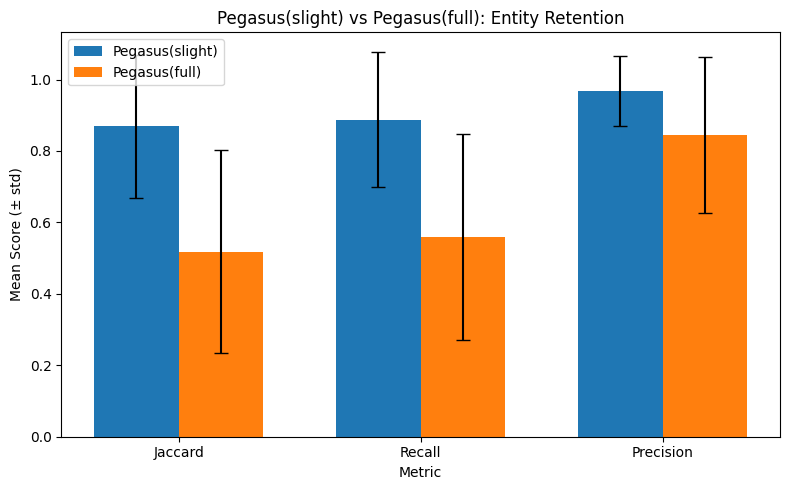

In [74]:
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, slight_means, width, yerr=slight_stds, capsize=5, label="Pegasus(slight)")
plt.bar(x + width/2, full_means, width, yerr=full_stds, capsize=5, label="Pegasus(full)")

plt.xticks(x, labels)
plt.xlabel("Metric")
plt.ylabel("Mean Score (± std)")
plt.title("Pegasus(slight) vs Pegasus(full): Entity Retention")
plt.legend()
plt.tight_layout()
plt.show()

In [75]:
pegasus_dataset = []

for ds, g in paired.groupby("dataset"):
    pegasus_dataset.append({
        "dataset": ds,
        "slight_jaccard": np.nanmean(g["pegasus_slight_jaccard"]),
        "full_jaccard": np.nanmean(g["pegasus_full_jaccard"]),
        "slight_recall": np.nanmean(g["pegasus_slight_recall"]),
        "full_recall": np.nanmean(g["pegasus_full_recall"]),
        "slight_precision": np.nanmean(g["pegasus_slight_precision"]),
        "full_precision": np.nanmean(g["pegasus_full_precision"]),
    })

pegasus_dataset_df = pd.DataFrame(pegasus_dataset)
pegasus_dataset_df

,dataset,slight_jaccard,full_jaccard,slight_recall,full_recall,slight_precision,full_precision
0,cmv,0.884749,0.546758,0.901100,0.586177,0.971584,0.861918
1,eli5,0.866015,0.509776,0.887207,0.548264,0.966222,0.838601
2,sci_gen,0.875865,0.466559,0.893074,0.499778,0.972958,0.838731
3,tldr,0.867196,0.510801,0.885169,0.548972,0.968067,0.847366
4,wp,0.884109,0.549539,0.907799,0.603342,0.964949,0.838459
5,xsum,0.837853,0.520051,0.856511,0.558257,0.961228,0.858101
6,yelp,0.878607,0.532631,0.897157,0.576036,0.967775,0.834788


In [76]:
pegasus_dataset_df.to_csv(OUT_DIR / "task3_pegasus_dataset_breakdown.csv", index=False)
print("Saved:", OUT_DIR / "task3_pegasus_dataset_breakdown.csv")

Saved: C:\Users\johns\Documents\ShipOfTheseus-NLP\experiments\stylometry_results\task3_pegasus_dataset_breakdown.csv


In a markdown cell (80–120 words) answer: Is the difference between the two Pegasus variants larger for Recall (dropping) or Precision (hallucination)? Is this pattern consistent across all 7 datasets, or does it vary by domain (e.g., news vs. reviews vs. scientific text)?

The difference between Pegasus(slight) and Pegasus(full) is larger for **Recall** than for **Precision**, indicating that increasing paraphrase coverage primarily leads to **entity dropping** rather than **entity hallucination**. Recall measures how many original entities from T0 are preserved in T1, while Precision measures whether entities in T1 were already present in T0.

Across all seven datasets, this pattern is highly consistent. Pegasus(full) shows a substantial drop in both Jaccard and Recall compared to Pegasus(slight), while Precision decreases to a lesser extent. This suggests that paraphrasing more sentences leads to greater loss of original entities, especially in content-heavy domains such as news and scientific text.

# Task 4 The Paraphraser Fingerprint Report

# Q1:
Across all datasets, Dipper(high) consistently produces lower cosine similarity than ChatGPT, indicating higher POS drift. Overall, Dipper(high) achieves a mean cosine similarity of **0.8802**, compared to **0.9678** for ChatGPT. 

This pattern is consistent across domains. For example, in the scientific domain (sci_gen), Dipper(high) has a cosine similarity of **0.8535**, while ChatGPT achieves **0.9768**. Similarly, in the review domain (yelp), Dipper(high) scores **0.8793**, compared to **0.9608** for ChatGPT. 

This shows that ChatGPT better preserves stylistic structure, while Dipper(high) introduces greater syntactic variation.

# Q2: 
Among the three paraphrasers, **dipper(high)** is the worst offender for both entity dropping and hallucination. It has the lowest Recall at **0.0403**, compared to **0.6255** for ChatGPT and **0.8880** for Pegasus(slight), indicating that it removes a large proportion of original entities. 

For hallucination, dipper(high) also has the lowest Precision at **0.0624**, significantly below ChatGPT (**0.7646**) and Pegasus(slight) (**0.9670**). This suggests that it frequently introduces new entities not present in the original text. These results show that dipper(high) is highly aggressive, causing both substantial content loss and substantial distortion.

# Q3:

In [78]:
paired.columns.tolist()

['dataset',
 'key',
 'source',
 'text_T0',
 'text_chatgpt',
 'text_dipper_high',
 'text_pegasus_slight',
 'pos_T0',
 'pos_dipper_high',
 'pos_chatgpt',
 'cos_sim_dipper',
 'cos_sim_chatgpt',
 'group',
 'text_pegasus_full',
 'ent_T0',
 'ent_chatgpt',
 'ent_dipper_high',
 'ent_pegasus_slight',
 'ent_pegasus_full',
 'chatgpt_jaccard',
 'chatgpt_recall',
 'chatgpt_precision',
 'dipper_high_jaccard',
 'dipper_high_recall',
 'dipper_high_precision',
 'pegasus_slight_jaccard',
 'pegasus_slight_recall',
 'pegasus_slight_precision',
 'pegasus_full_jaccard',
 'pegasus_full_recall',
 'pegasus_full_precision']

In [79]:
import pandas as pd
from pathlib import Path

ROOT = Path("..").resolve()
RAW_DIR = ROOT / "data" / "raw" / "paraphrased_datasets"
OUT_DIR = ROOT / "experiments" / "stylometry_results"

files = sorted(RAW_DIR.glob("*_paraphrased.csv"))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["dataset"] = f.name.replace("_paraphrased.csv", "")
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.columns = [c.strip().lower() for c in df_all.columns]

if "version" not in df_all.columns and "version_name" in df_all.columns:
    df_all = df_all.rename(columns={"version_name": "version"})

In [80]:
dip_low = df_all.copy()
dip_low["version"] = dip_low["version"].astype(str).str.strip()

dip_low = dip_low[dip_low["version"] == "dipper(low)"].copy()
dip_low = dip_low[["dataset", "key", "source", "text"]].rename(
    columns={"text": "text_dipper_low"}
)

dip_low.head()

,dataset,key,source,text_dipper_low
25649,cmv,cmv-258,Tsinghua,"Before I begin, I would like to point out som..."
25650,cmv,cmv-258,Eleuther-AI,"Before I begin, I would like to point out som..."
25651,cmv,cmv-258,LLAMA,"Before I begin, I would like to point out som..."
25652,cmv,cmv-258,OpenAI,I would like to point out something before I ...
25653,cmv,cmv-258,BigScience,Before I begin I would like to point somethin...


In [81]:
paired = paired.merge(
    dip_low,
    on=["dataset", "key", "source"],
    how="left"
)

"text_dipper_low" in paired.columns, paired["text_dipper_low"].notna().sum()

(True, np.int64(19182))

In [82]:
paired.to_pickle(OUT_DIR / "paired_with_dipper_low.pkl")
paired.to_csv(OUT_DIR / "paired_with_dipper_low.csv", index=False)

print("saved:", OUT_DIR / "paired_with_dipper_low.pkl")

saved: C:\Users\johns\Documents\ShipOfTheseus-NLP\experiments\stylometry_results\paired_with_dipper_low.pkl


In [83]:
paired["pos_dipper_low"] = [
    get_pos_distribution(t) for t in paired["text_dipper_low"]
]

In [84]:
cos_low = []

for _, row in paired.iterrows():
    v1 = dict_to_vector(row["pos_T0"], ALL_POS)
    v2 = dict_to_vector(row["pos_dipper_low"], ALL_POS)
    cos_low.append(cosine_similarity(v1, v2))

paired["cos_sim_dipper_low"] = cos_low

In [85]:
low_mean = np.nanmean(paired["cos_sim_dipper_low"])
low_std = np.nanstd(paired["cos_sim_dipper_low"])

print(f"Dipper(low): {low_mean:.4f} ± {low_std:.4f}")

Dipper(low): 0.9841 ± 0.0304


In [86]:
paired["ent_dipper_low"] = extract_entity_sets_batch(paired["text_dipper_low"])

processed 1000/19182
processed 2000/19182
processed 3000/19182
processed 4000/19182
processed 5000/19182
processed 6000/19182
processed 7000/19182
processed 8000/19182
processed 9000/19182
processed 10000/19182
processed 11000/19182
processed 12000/19182
processed 13000/19182
processed 14000/19182
processed 15000/19182
processed 16000/19182
processed 17000/19182
processed 18000/19182
processed 19000/19182


In [87]:
paired["dipper_low_recall"] = paired.apply(
    lambda row: (
        len(row["ent_T0"] & row["ent_dipper_low"]) / len(row["ent_T0"])
        if len(row["ent_T0"]) > 0 else np.nan
    ),
    axis=1
)

In [88]:
low_recall_mean = np.nanmean(paired["dipper_low_recall"])
low_recall_std = np.nanstd(paired["dipper_low_recall"])

print(f"Dipper(low) Recall: {low_recall_mean:.4f} ± {low_recall_std:.4f}")

Dipper(low) Recall: 0.6497 ± 0.2808


In [89]:
print(f"Dipper(low): {low_mean:.4f} ± {low_std:.4f}")
print(f"Dipper(low) Recall: {low_recall_mean:.4f} ± {low_recall_std:.4f}")

Dipper(low): 0.9841 ± 0.0304
Dipper(low) Recall: 0.6497 ± 0.2808


# Q3:

Increasing Dipper intensity leads to stronger changes in both style and content, but the impact is significantly larger for content. For stylistic change, the cosine similarity decreases from **0.9841** for dipper(low) to **0.8802** for dipper(high), indicating increased POS drift.

However, the effect on content is much more pronounced: Recall drops from **0.6497** for dipper(low) to **0.0403** for dipper(high), showing a substantial loss of original entities. This indicates that higher intensity paraphrasing disproportionately affects semantic content rather than stylistic variation.

This suggests that for RQ1, increasing paraphrasing strength sacrifices content fidelity more than it enhances stylistic transformation, making high-intensity paraphrasing less suitable when preserving meaning is important.